# RadarScenes Object Classification: From Single Scan to Multi-Scan Tracks

Single-scan and multi-scan (track-level) results, one document. Single-scan work
uses the DeepReflecs point-set encoder trained fresh on this project's taxonomy;
multi-scan work accumulates a tracked object's points across its last N radar scans
before classifying. All numbers are single fixed-split results (sequence-grouped
train/val/test, one canonical split reused everywhere), not fold-averaged unless
stated.

## Abstract

A single RadarScenes detection instance (one object, one scan) averages only ~2.9
points. A DeepReflecs point-set classifier trained on single scans (all 4 sensors)
reaches just 0.7370 macro F1 across the five target classes (`car`, `large_vehicle`,
`two_wheeler`, `pedestrian`, `pedestrian_group`), a sparsity ceiling, not a model
capacity one. That motivates accumulating a tracked object's points across its last
N radar scans instead of classifying each scan in isolation.

A naive pooled baseline (DeepReflecs, N=20 scans, all sensors, no notion of scan
order at all) already reaches 0.8635 macro F1 purely from more points per decision.
The best result (0.8897 macro F1) adds a causal GRU that consumes the sequence of
per-scan embeddings directly (order-aware, one hidden state per track), fused with
the order-blind pooled embedding through a small trained classifier head.

The fusion model's confusion matrix shows two dominant error axes: 15% of
`large_vehicle` tracks get misclassified as `car` (the reverse barely happens, 3.8%),
and `pedestrian`/`pedestrian_group` confuse each other in both directions (6.6% and
8.6%), consistent with those being genuinely ambiguous radar signatures (a large car
vs. a small truck; one person vs. a loose group) rather than a model-specific
weakness.

## 1. The RadarScenes dataset

[RadarScenes](https://radar-scenes.com/) (Schumann et al., *RadarScenes: A Real-World
Radar Point Cloud Data Set for Automotive Applications*, arXiv:2104.02493, 2021) is a
real-world automotive radar dataset: 4 series-production radar sensors mounted on a
test vehicle, overlapping fields of view, point-level semantic labels propagated from
camera-verified object tracks.

![RadarScenes sensor layout, sensor 2 highlighted](../results/radarscenes_sensor_layout.png)

This project's taxonomy merges RadarScenes' own finer-grained labels into 5 classes
(`car`, `large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`); `large_vehicle`
folds in `truck`/`train`/`bus` (near-chance pairwise separability from `car`-sized
vehicles at the raw-class level, and `train`/`bus` individually too thin to split
without leakage). All 4 sensors share one global clock, which the multi-scan work
below (Section 4) relies on directly.

## 2. Single-scan baseline: DeepReflecs

DeepReflecs (Ulrich, Glaser & Timm, *DeepReflecs: Deep Learning for Automotive Object
Classification with Radar Reflections*, IEEE RadarConf 2021,
[arXiv:2010.09273](https://arxiv.org/abs/2010.09273)) is a per-point shared-weight
network (PointNet-style): the same small MLP processes every point independently, so
the model is order-invariant and works on a variable number of points by
construction, the right inductive bias for an unordered radar point cloud. This
project adapts its input features to what RadarScenes provides (`x_rel`, `y_rel`,
`rcs`, `vr_compensated`, `range_sc`), not a literal reproduction of the paper's own
feature set.

What sets it apart from a plain PointNet baseline: the **global context layer** sits
*between* the two per-point stages, not only at the very end, so the second per-point
layer already has access to a permutation-invariant summary (mean/max) of the whole
point set before producing its own output. A **masked global max-pool** then reduces
the (variable-length) point set to one fixed embedding: max, not mean or sum, because
it is the aggregation that stays invariant to how many padding points get added,
picking out the most salient reading per channel regardless of point count.

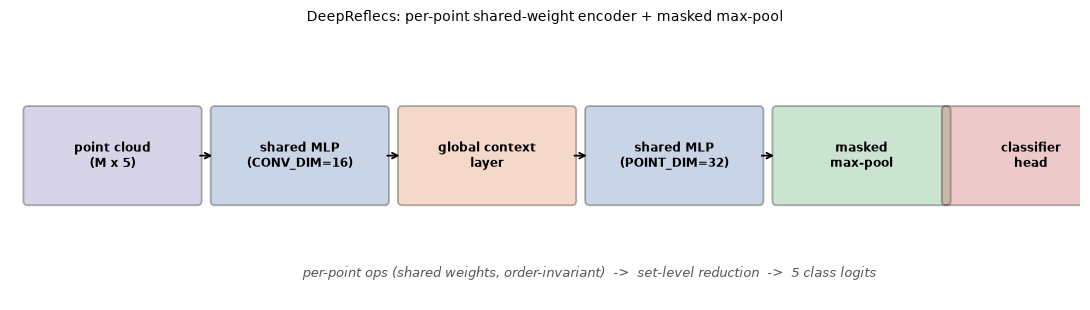

In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 3)
ax.axis("off")

stages = [
    (0.2, 1.6, "point cloud\n(M x 5)", "#8172B2"),
    (2.3, 1.6, "shared MLP\n(CONV_DIM=16)", "#4C72B0"),
    (4.4, 1.6, "global context\nlayer", "#DD8452"),
    (6.5, 1.6, "shared MLP\n(POINT_DIM=32)", "#4C72B0"),
    (8.6, 1.6, "masked\nmax-pool", "#55A868"),
    (10.5, 1.6, "classifier\nhead", "#C44E52"),
]
w, h = 1.9, 1.0
for x, y, label, color in stages:
    ax.add_patch(mpatches.FancyBboxPatch((x, y - h / 2), w, h, boxstyle="round,pad=0.05",
                                           linewidth=1.3, edgecolor="k", facecolor=color, alpha=0.3))
    ax.text(x + w / 2, y, label, ha="center", va="center", fontsize=8.5, fontweight="bold")

for (x1, y1, _, _), (x2, y2, _, _) in zip(stages[:-1], stages[1:]):
    ax.annotate("", xy=(x2, y2), xytext=(x1 + w, y1), arrowprops=dict(arrowstyle="->", color="k", lw=1.3))

ax.text(6.5, 0.3, "per-point ops (shared weights, order-invariant)  ->  set-level reduction  ->  5 class logits",
        ha="center", va="center", fontsize=9, style="italic", color="#555")
ax.set_title("DeepReflecs: per-point shared-weight encoder + masked max-pool", fontsize=10)
fig.tight_layout()
plt.show()


car                    0.942     0.816     0.874     76572
large_vehicle          0.676     0.782     0.725     15555
two_wheeler            0.522     0.777     0.625     11466
pedestrian             0.664     0.884     0.758     35091
pedestrian_group       0.810     0.621     0.703     40081

macro F1: 0.7370


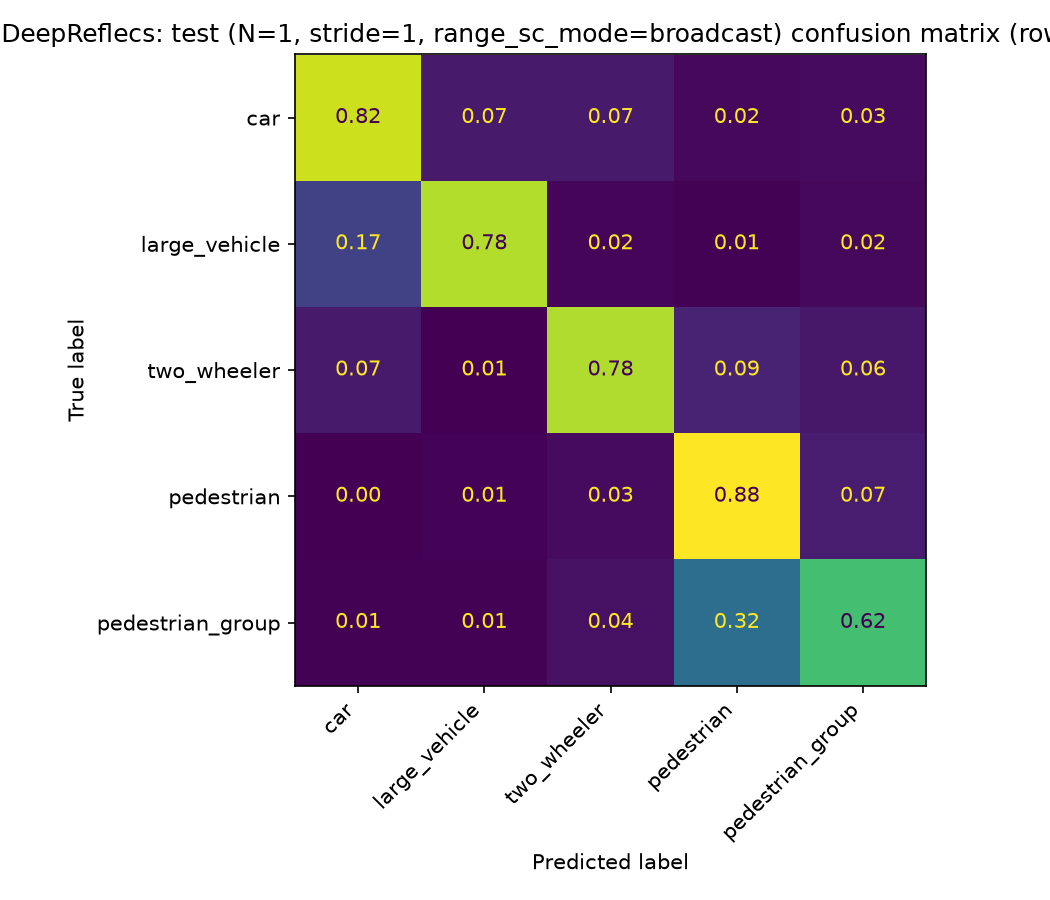

In [2]:

import json
from pathlib import Path
from IPython.display import Image, display

RESULTS = Path("/home/bruno/radar_machine_learning_ws/results")

metrics = json.loads((RESULTS / "track_accumulation/N1_stride1_allsensors/deepreflecs_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation/N1_stride1_allsensors/deepreflecs_test_confusion_matrix.png")))


**Single-scan baseline: macro F1 = 0.7370.** `car` is the strongest class (F1
0.874, most points per instance, most rigid/consistent signature); `two_wheeler` is
the weakest (F1 0.625, sparsest class, easily confused with `car`/`pedestrian` at
this point-count regime). This is the floor every multi-scan result below improves
on.

## 3. Motivation: why accumulate scans

- A single detection instance averaging ~2.9 points hits a hard ceiling regardless of
  encoder: histograms, explicit per-instance statistics, and DeepReflecs' learned
  point-set network all converge to a similar macro F1 band on single-scan data
  (Section 2). The bottleneck is point count, not model choice.
- A `track_id` persists across a tracked object's lifetime, multiple radar scans of
  the *same* object, and all 4 sensors share one global clock. Pooling a track's last
  N scans' points into one decision, instead of one scan's points, attacks sparsity
  directly at the input level rather than trying to encode more out of the same few
  points.
- A second, independent lever: building a window from whichever sensor(s) are
  actually detecting the track *right now* (cross-sensor handoff) gets more real
  detections per track without needing more real time to pass, since a track is
  often seen by 2-3 different sensors as it moves through overlapping fields of
  view.
- Coordinate frame matters once points from different scans get pooled: the car
  frame (`x_cc`/`y_cc`) rotates with ego heading and is unusable across scans; the
  global odometry-corrected frame (`x_seq`/`y_seq`), recentered per scan on that
  scan's own object centroid (`x_rel`/`y_rel` = `x_seq`/`y_seq` minus that scan's
  own mean), is what actually goes into the model, bounded scan-to-scan instead of
  drifting with the object's accumulated path.

## 4. Multi-scan baseline: naive pooling

All points from a track's last `N=20` scans (all sensors) concatenated into **one**
point set, classified by a single DeepReflecs instance trained end-to-end on the
pooled data. No sequence model, no per-scan structure retained, no notion of which
point came from which scan at all: this is what "just throw more points at the same
architecture" buys, the reference every subsequent addition below has to clear.

car                    0.954     0.914     0.933     76572
large_vehicle          0.801     0.834     0.817     15555
two_wheeler            0.748     0.891     0.813     11466
pedestrian             0.861     0.921     0.890     35091
pedestrian_group       0.888     0.841     0.864     40081

macro F1: 0.8635


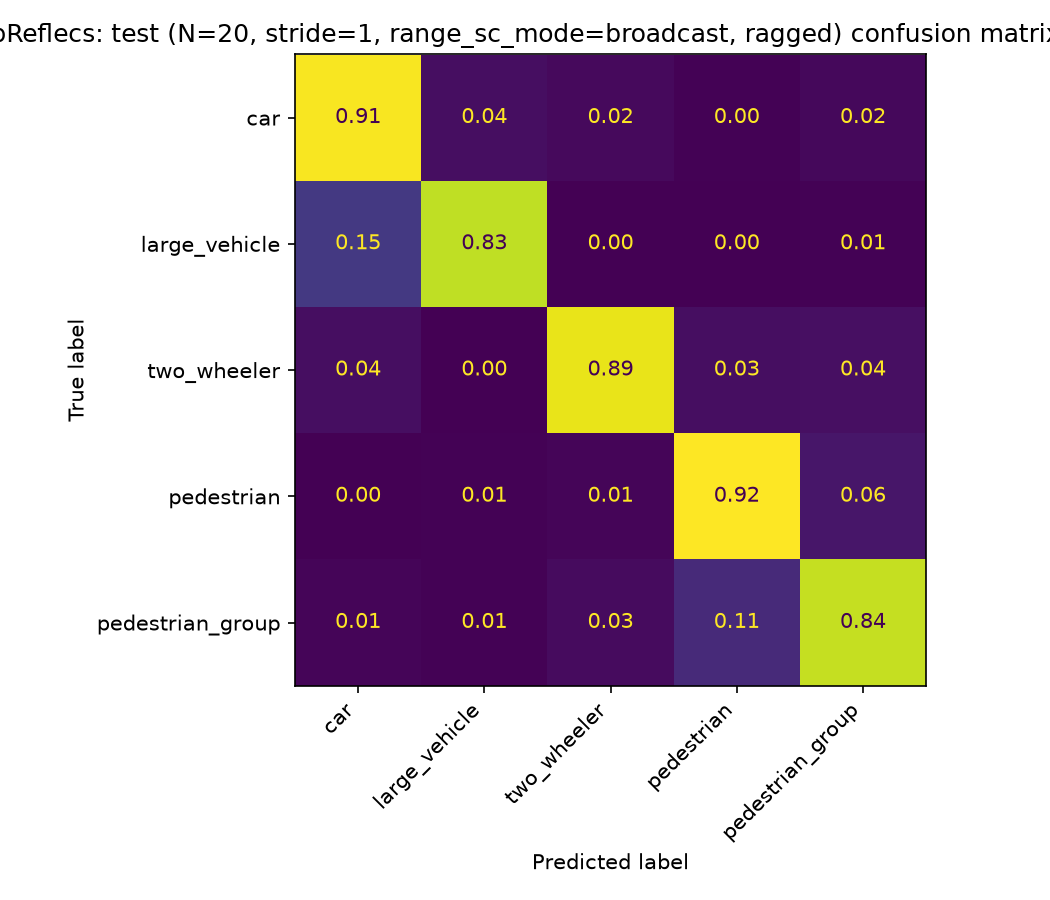

In [3]:

metrics = json.loads((RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_metrics.json").read_text())
macro_f1 = sum(m["f1"] for m in metrics.values()) / len(metrics)
for c, m in metrics.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"\nmacro F1: {macro_f1:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation/N20_stride1_allsensors/deepreflecs_test_confusion_matrix.png")))


**Baseline: macro F1 = 0.8635**, +0.1265 over the single-scan floor from pooling
alone, no new architecture. Weakest class is still `two_wheeler` (F1 0.813), but
every class improved substantially over Section 2's single-scan numbers.

## 5. Sequence model: GRU, and fusion with the pooled view

A frozen, already-trained DeepReflecs encoder (single-scan, `x_seq`/`y_seq` frame)
reduces each scan to one embedding vector; a GRU then consumes the sequence of a
track's embeddings causally (a verdict at scan t only depends on scans up to and
including t, so it stays usable in real-time streaming inference). The encoder runs
once per scan across the whole dataset, not once per window, so a sliding window's
scan-to-scan overlap costs nothing extra in encoder compute.

**Fusion** concatenates this GRU's final hidden state (order-aware) with the pooled,
order-blind embedding from Section 4's baseline, then trains a small classifier head
on the concatenation, both branches frozen. Structurally analogous to a U-Net skip
connection (Ronneberger, Fischer & Brox, MICCAI 2015): splice in a view the deeper
path's own bottleneck might otherwise discard, instead of forcing one representation
to carry everything.

GRU alone:
car                    0.952     0.935     0.944     76572
large_vehicle          0.817     0.841     0.829     15555
two_wheeler            0.844     0.909     0.875     11466
pedestrian             0.895     0.905     0.900     35091
pedestrian_group       0.904     0.895     0.900     40081
macro F1: 0.8895

Fusion (pooled + GRU h=64):
car                    0.953     0.933     0.943     76572
large_vehicle          0.810     0.845     0.827     15555
two_wheeler            0.849     0.906     0.877     11466
pedestrian             0.888     0.914     0.901     35091
pedestrian_group       0.910     0.890     0.900     40081
macro F1: 0.8897


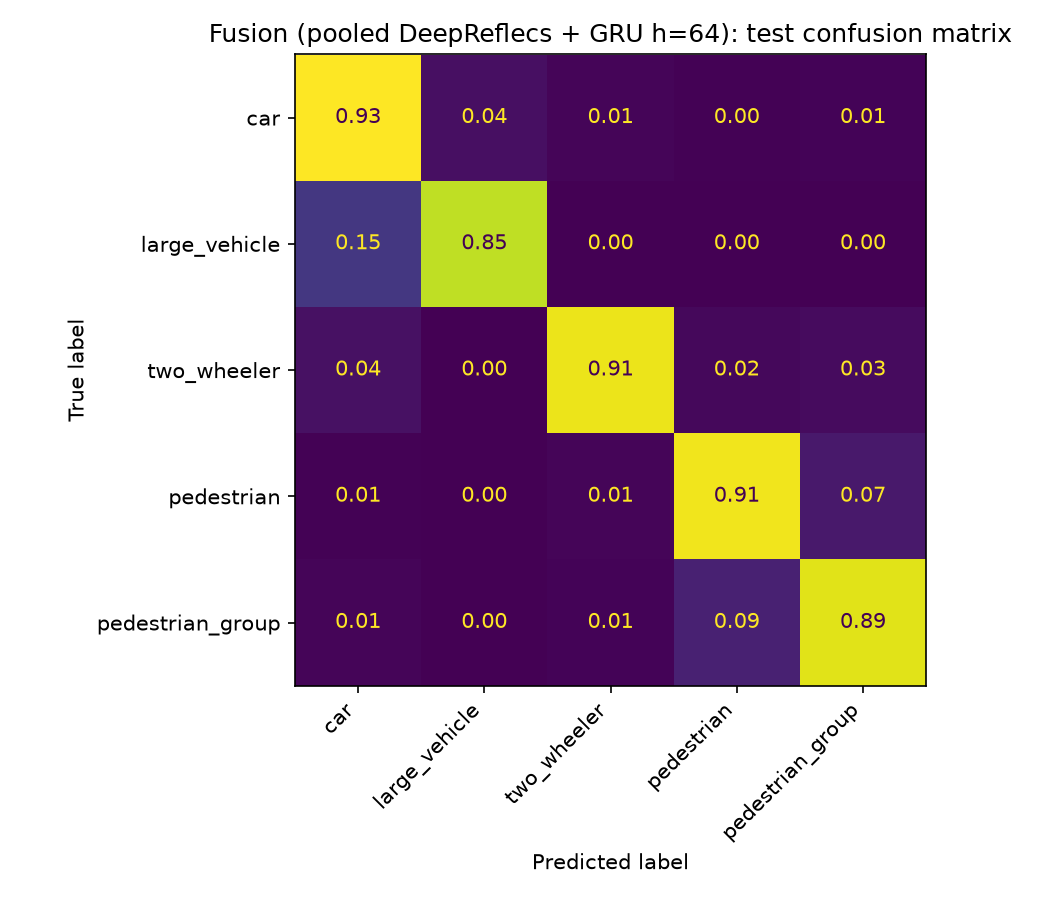

In [4]:

metrics_gru = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_gru_h64_allsensors/gru_test_metrics.json").read_text())
macro_f1_gru = sum(m["f1"] for m in metrics_gru.values()) / len(metrics_gru)
print("GRU alone:")
for c, m in metrics_gru.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"macro F1: {macro_f1_gru:.4f}\n")

metrics_fusion = json.loads((RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_metrics.json").read_text())
macro_f1_fusion = sum(m["f1"] for m in metrics_fusion.values()) / len(metrics_fusion)
print("Fusion (pooled + GRU h=64):")
for c, m in metrics_fusion.items():
    print(f"{c:<18}{m['precision']:>10.3f}{m['recall']:>10.3f}{m['f1']:>10.3f}{m['support']:>10}")
print(f"macro F1: {macro_f1_fusion:.4f}")

display(Image(filename=str(RESULTS / "track_accumulation_rnn/N20_stride1_fusion_pooled_gru64_allsensors/fusion_test_confusion_matrix.png")))


**GRU alone: macro F1 = 0.8895** (+0.0260 over the pooling baseline). **Fusion:
macro F1 = 0.8897** (+0.0002 over GRU alone, within this branch's own noise band for
a single split, not a real additional gain). The best overall result either way.

**Confusion matrix, fusion model.** Two dominant error axes: `large_vehicle` -> `car`
at 15% (the reverse direction is only 3.8%), and `pedestrian` <-> `pedestrian_group`
confuse each other both ways (6.6% and 8.6%). Both read as genuinely ambiguous radar
signatures, a large car and a small truck, or one person and a loose group, rather
than a fixable model weakness: `car` is the class every `large_vehicle` error falls
into, and the pedestrian/group confusion is symmetric, not a one-directional bias.

## 6. Ablation studies (brief)

Everything below is single-split, not fold-validated. Full detail and every
individual result: `track_accumulation.md`.

| what was tried | result vs. its own reference | reads as |
|---|---|---|
| More GRU capacity (h=128) | Worse or flat vs. h=64 at every N/sensor scale tested | Not capacity-starved; more parameters overfit rather than help |
| Temporal-variation scalar (scan-to-scan RCS/Doppler diff) added to the pooled or GRU representation | Small, inconsistent gains (+0.001 to +0.013 depending on N/sensor), never large | Genuine but marginal signal, sensitive to how it's normalized across cross-sensor time gaps |
| End-to-end fine-tuning (warmstart) of either the pooled encoder or the GRU's own per-scan encoder, at N=20 all-sensor | Both land *below* their frozen baselines (-0.0029, -0.0017) | An already-good frozen encoder already sits near this task's ceiling; the one N=10 sensor2-only warmstart win doesn't generalize to this scale |
| Post-hoc probability smoothing (causal, along a track) on the fusion model's output | Small positive: +0.0013 (moving average, K=5) to +0.0031 (IIR low-pass, same span) | Free accuracy at inference time, not a training-time fix |
| Other sequence-mixing architectures (Transformer, a selective state-space model, point-level self-attention), same frozen per-scan embeddings | All land inside the same ~0.86-0.89 macro F1 band as GRU/fusion | The bottleneck is upstream of which sequence-mixing mechanism is used, not solved by trying a different one |

Every lever that changed something structural (pooling itself, cross-sensor handoff,
more N) moved the number by multiple points; every lever that only changed *how* the
already-pooled or already-sequenced information gets processed moved it by a point
or less.

## 7. Conclusions and future work

Multi-scan accumulation is the real lever: pooling alone recovers most of the gap
from the single-scan floor (0.7370 -> 0.8635), and a causal GRU plus fusion recovers
a further, smaller amount (-> 0.8897). Architecture search *within* the sequence-mixing
stage (capacity, warmstarting, alternative mechanisms) has consistently returned the
same answer, further gains there are not where the remaining headroom is.

**Concrete next steps, in order of expected information gained per hour spent:**

1. **Fold-validate the current best configuration.** Every number in this report is
   a single split; the branch's own repeated finding is that differences under
   roughly a point should be read as ties, not ranked results, without this check.
2. **Error overlap analysis.** Cross-reference the fusion model's misclassified
   tracks against GRU alone and the other architectures tried. If the same tracks
   are wrong everywhere, the ceiling is in the data/labels, not any one model.
3. **Manual inspection of confident errors**, especially `large_vehicle` predicted as
   `car` and `pedestrian` vs. `pedestrian_group`, directly against the raw point
   clouds and RadarScenes ground truth, since both read as plausibly ambiguous even
   to a human annotator.
4. **Question the frozen per-scan embedding itself.** Every sequence model shares the
   same frozen DeepReflecs per-scan encoder as input; if that encoder is the actual
   bottleneck, no amount of downstream sequence-mixing sophistication will move the
   number.
5. **Not recommended as a next step**: another sequence-mixing architecture on top of
   the same frozen embeddings. Multiple independently different mechanisms have
   already returned the same answer; a new one would need a specific, falsifiable
   reason to expect otherwise.